# Ablation Training
Modes:
  * `'full'`         — full model (sanity check / paper baseline row)
  * `'no_dt'`        — A1: zero out Δt embedding
  * `'no_content'`   — A2: zero out cross-attention content code
  * `'discrete_dt'`  — A3: bucketed Δt instead of continuous sinusoidal
  * `'concat_cond'`  — A4: channel-concat source latent instead of xattn
  * `'no_film'`      — A5: replace FiLM with extra cross-attention tokens


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
ABLATION_MODE = 'discrete_dt'      # 'full' | 'no_dt' | 'no_content' | 'discrete_dt' | 'concat_cond' | 'no_film'

import os, math, json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from skimage.metrics import structural_similarity as ssim_fn


In [ ]:
DRIVE_ROOT   = '/content/drive/MyDrive/JHU/GMCV/project'
MANIFEST_CSV = os.path.join(DRIVE_ROOT, 'manifests', 'slices_manifest_50.csv')
VAE_CKPT     = os.path.join(DRIVE_ROOT, 'PHASE1_VAE', 'sample_50', 'vae_phase1.pt')   # YOUR existing Phase I VAE
RESULTS      = Path(DRIVE_ROOT) / 'BASELINE' / 'ABLATION'
RESULTS.mkdir(parents=True, exist_ok=True)
TAG          = f'{ABLATION_MODE}'
CKPT_PATH    = RESULTS / f'{TAG}_ckpt.pt'
PRED_DIR     = RESULTS / f'{TAG}_preds'; PRED_DIR.mkdir(parents=True, exist_ok=True)


In [ ]:
IMG_SIZE     = 256
LATENT_SIZE  = 32            # spatial size of VAE latent (e.g. 192/8)
LATENT_CH    = 64             # number of VAE latent channels
BATCH_SIZE   = 64
EPOCHS       = 60
LR           = 1e-4
TIMESTEPS    = 1000
DDIM_STEPS   = 50
USE_LPIPS    = True
SEED         = 0

# Δt-bucket boundaries (days) — used by `discrete_dt` mode AND by Δt-bucket eval
DT_BUCKET_EDGES = [90, 270]        # → 3 buckets: short / med / long

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(SEED); np.random.seed(SEED)
print(f'Device: {DEVICE}  |  ABLATION_MODE={ABLATION_MODE}  |  TAG={TAG}')


Device: cuda  |  ABLATION_MODE=discrete_dt  |  TAG=chronodiff_discrete_dt


In [ ]:
df = pd.read_csv(MANIFEST_CSV)

# Define the old and new path prefixes
old_path = '/content/drive/MyDrive/project/dataset/'
new_path = '/content/drive/MyDrive/JHU/GMCV/project/dataset/'

# Update the 'slice_t' column
df['slice_t'] = df['slice_t'].str.replace(old_path, new_path, regex=False)

# Update the 'slice_next' column
df['slice_next'] = df['slice_next'].str.replace(old_path, new_path, regex=False)

df.head(3)

train_df = df[df.split == 'train'].reset_index(drop=True)
val_df   = df[df.split == 'val'  ].reset_index(drop=True)
test_df  = df[df.split == 'test' ].reset_index(drop=True)
print(f'train={len(train_df):,}  val={len(val_df):,}  test={len(test_df):,}')


train=17,108  val=1,633  test=5,441


In [ ]:
class PairDataset(Dataset):
    def __init__(self, df): self.df = df.reset_index(drop=True)
    def __len__(self): return len(self.df)
    def _load(self, p):
        x = np.load(p).astype(np.float32)
        dr = max(x.max(), 1e-6)
        return np.clip(x / dr, 0, 1) * 2 - 1
    def __getitem__(self, i):
        r = self.df.iloc[i]
        return {
            'src'     : torch.from_numpy(self._load(r['slice_t'])  ).unsqueeze(0).float(),
            'tgt'     : torch.from_numpy(self._load(r['slice_next'])).unsqueeze(0).float(),
            'dt'      : torch.tensor(r['delta_t_days'], dtype=torch.float32),
            'slice_id': r['slice_id'],
        }

train_loader = DataLoader(PairDataset(train_df), batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=2, pin_memory=True,
                          drop_last=True, persistent_workers=True)
val_loader   = DataLoader(PairDataset(val_df),   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True,
                          persistent_workers=True)
test_loader  = DataLoader(PairDataset(test_df),  batch_size=1,
                          shuffle=False, num_workers=2, pin_memory=True,
                          persistent_workers=True)


## Phase I VAE load existing checkpoint


In [ ]:
import torch
import torch.nn as nn

class ConditionalVAE(nn.Module):
    def __init__(self, latent_ch=64, base_ch=32):
        super().__init__()

        num_groups = 8

        self.enc = nn.Sequential(
            # Input: (1, 256, 256)
            nn.Conv2d(1, base_ch, kernel_size=4, stride=2, padding=1),            # enc.0
            nn.GroupNorm(num_groups, base_ch),                                    # enc.1
            nn.SiLU(),                                                            # enc.2

            # (32, 128, 128) -> (64, 64, 64)
            nn.Conv2d(base_ch, base_ch * 2, kernel_size=4, stride=2, padding=1),  # enc.3
            nn.GroupNorm(num_groups, base_ch * 2),                                # enc.4
            nn.SiLU(),                                                            # enc.5

            # (64, 64, 64) -> (128, 32, 32)
            nn.Conv2d(base_ch * 2, base_ch * 4, kernel_size=4, stride=2, padding=1),# enc.6
            nn.GroupNorm(num_groups, base_ch * 4),                                # enc.7
            nn.SiLU()                                                             # enc.8
        )

        # Maps 128 channels -> 128 channels (64 for mu, 64 for logvar)
        self.to_latent = nn.Conv2d(base_ch * 4, latent_ch * 2, kernel_size=1)

        # Maps 64 latent channels -> 128 channels
        self.from_latent = nn.Conv2d(latent_ch, base_ch * 4, kernel_size=1)

        self.dec = nn.Sequential(
            nn.SiLU(),                                                                      # dec.0
            nn.ConvTranspose2d(base_ch * 4, base_ch * 2, kernel_size=4, stride=2, padding=1), # dec.1
            nn.GroupNorm(num_groups, base_ch * 2),                                          # dec.2
            nn.SiLU(),                                                                      # dec.3

            nn.ConvTranspose2d(base_ch * 2, base_ch, kernel_size=4, stride=2, padding=1),     # dec.4
            nn.GroupNorm(num_groups, base_ch),                                              # dec.5
            nn.SiLU(),                                                                      # dec.6

            nn.ConvTranspose2d(base_ch, 1, kernel_size=4, stride=2, padding=1)                # dec.7
        )

    def encode(self, x):
        h = self.enc(x)
        h = self.to_latent(h)
        # Split channels into mu and log variance
        mu, logvar = h.chunk(2, dim=1)
        return mu, logvar

    def decode(self, z):
        h = self.from_latent(z)
        h = self.dec(h)
        return torch.sigmoid(h)

vae = ConditionalVAE(latent_ch=LATENT_CH).to(DEVICE).eval()
if Path(VAE_CKPT).exists():
    state = torch.load(VAE_CKPT, map_location=DEVICE)
    state = state.get('model', state.get('state_dict', state))
    try:
        vae.load_state_dict(state)
        print(f'Loaded VAE checkpoint from {VAE_CKPT}')
    except Exception as e:
        print(f'WARN: VAE state dict mismatch ({e}). Replace PlaceholderVAE '
              f'with your actual VAE class before running real ablations.')
else:
    print(f'WARN: no VAE checkpoint at {VAE_CKPT}. Running with random VAE — '
          f'fine for plumbing tests, not for paper results.')

for p in vae.parameters(): p.requires_grad_(False)

@torch.no_grad()
def encode_pair(src, tgt):
    """Returns (latent_src, latent_tgt) in shape [B, LATENT_CH, LATENT_SIZE, LATENT_SIZE]."""
    mu_s, _ = vae.encode(src); mu_t, _ = vae.encode(tgt)
    return mu_s, mu_t

@torch.no_grad()
def decode_latent(z):
    return vae.decode(z)


Loaded VAE checkpoint from /content/drive/MyDrive/JHU/GMCV/project/chronodiff/PHASE1_VAE/sample_50/vae_phase1.pt


In [ ]:
def sinusoidal(t, dim=128, max_period=10000):
    half = dim // 2
    freqs = torch.exp(-math.log(max_period) *
                      torch.arange(half, device=t.device) / half)
    a = t[:, None].float() * freqs[None]
    return torch.cat([torch.cos(a), torch.sin(a)], -1)

def dt_to_bucket(dt):
    """Map Δt (days) to discrete bucket id in {0, 1, 2}."""
    b = torch.zeros_like(dt, dtype=torch.long)
    b = torch.where(dt >= DT_BUCKET_EDGES[0], torch.ones_like(b), b)
    b = torch.where(dt >= DT_BUCKET_EDGES[1], 2 * torch.ones_like(b), b)
    return b

class FiLM(nn.Module):
    def __init__(self, ch_emb, ch_feat):
        super().__init__()
        self.to_gb = nn.Linear(ch_emb, 2 * ch_feat)
    def forward(self, x, emb):
        g, b = self.to_gb(emb).chunk(2, -1)
        return x * (1 + g[..., None, None]) + b[..., None, None]

class XAttn(nn.Module):
    def __init__(self, ch, ctx_ch, heads=4):
        super().__init__()
        self.h = heads
        self.q = nn.Conv2d(ch, ch, 1)
        self.k = nn.Linear(ctx_ch, ch)
        self.v = nn.Linear(ctx_ch, ch)
        self.o = nn.Conv2d(ch, ch, 1)
    def forward(self, x, ctx):
        B, C, H, W = x.shape
        q = self.q(x).view(B, self.h, C // self.h, H * W).transpose(-1, -2)
        k = self.k(ctx).view(B, -1, self.h, C // self.h).transpose(1, 2)
        v = self.v(ctx).view(B, -1, self.h, C // self.h).transpose(1, 2)
        a = torch.softmax((q @ k.transpose(-1, -2)) / math.sqrt(C // self.h), -1)
        o = (a @ v).transpose(-1, -2).reshape(B, C, H, W)
        return x + self.o(o)

class ResBlock(nn.Module):
    def __init__(self, ci, co, emb_dim, ctx_ch=None):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, ci); self.conv1 = nn.Conv2d(ci, co, 3, padding=1)
        self.norm2 = nn.GroupNorm(8, co); self.conv2 = nn.Conv2d(co, co, 3, padding=1)
        self.film  = FiLM(emb_dim, co)
        self.skip  = nn.Conv2d(ci, co, 1) if ci != co else nn.Identity()
        self.xattn = XAttn(co, ctx_ch) if ctx_ch is not None else None
        self.use_film = True
    def forward(self, x, emb, ctx=None):
        h = self.conv1(F.silu(self.norm1(x)))
        if self.use_film: h = self.film(h, emb)
        h = self.conv2(F.silu(self.norm2(h)))
        h = h + self.skip(x)
        if self.xattn is not None and ctx is not None:
            h = self.xattn(h, ctx)
        return h


## U-Net — switch behavior with ABLATION_MODE


In [ ]:
class CondUNet(nn.Module):
    def __init__(self, mode, latent_ch=LATENT_CH, ch=128, emb_dim=256, ctx_ch=128):
        super().__init__()
        self.mode = mode
        # Δt embedding pathway (sinusoidal OR discrete lookup)
        if mode == 'discrete_dt':
            self.emb_dt = nn.Sequential(nn.Embedding(3, emb_dim),
                                        nn.SiLU(), nn.Linear(emb_dim, emb_dim))
        else:
            self.emb_dt = nn.Sequential(nn.Linear(128, emb_dim),
                                        nn.SiLU(), nn.Linear(emb_dim, emb_dim))
        self.emb_t   = nn.Sequential(nn.Linear(128, emb_dim),
                                     nn.SiLU(), nn.Linear(emb_dim, emb_dim))

        # Content code projection (for cross-attention modes)
        self.content_proj = nn.Conv2d(latent_ch, ctx_ch, 1)

        # Extra cross-attention token used in no_film mode for time
        if mode == 'no_film':
            self.time_tokens = nn.Linear(emb_dim, 4 * ctx_ch)  # 4 tokens

        # Input channels: latent_ch normally, 2*latent_ch in concat_cond mode
        in_ch = 2 * latent_ch if mode == 'concat_cond' else latent_ch
        use_xattn = mode not in ('concat_cond',)
        use_film  = mode != 'no_film'

        self.in_conv = nn.Conv2d(in_ch, ch, 3, padding=1)
        self.d1 = ResBlock(ch,   ch,   emb_dim, ctx_ch if use_xattn else None)
        self.d2 = ResBlock(ch,   2*ch, emb_dim, ctx_ch if use_xattn else None)
        self.d3 = ResBlock(2*ch, 4*ch, emb_dim, ctx_ch if use_xattn else None)
        self.mid = ResBlock(4*ch, 4*ch, emb_dim, ctx_ch if use_xattn else None)
        self.u3 = ResBlock(8*ch, 2*ch, emb_dim, ctx_ch if use_xattn else None)
        self.u2 = ResBlock(4*ch,   ch, emb_dim, ctx_ch if use_xattn else None)
        self.u1 = ResBlock(2*ch, latent_ch, emb_dim, ctx_ch if use_xattn else None)
        for m in [self.d1, self.d2, self.d3, self.mid, self.u3, self.u2, self.u1]:
            m.use_film = use_film
        self.out_conv = nn.Conv2d(latent_ch, latent_ch, 3, padding=1)

    def _emb(self, t, dt):
        # Δt
        if self.mode == 'discrete_dt':
            e_dt = self.emb_dt(dt_to_bucket(dt))
        else:
            e_dt = self.emb_dt(sinusoidal(dt))
        # Mode A1: zero Δt embedding entirely
        if self.mode == 'no_dt':
            e_dt = torch.zeros_like(e_dt)
        e_t = self.emb_t(sinusoidal(t))
        return e_t + e_dt

    def _ctx(self, z_src, B):
        # Build content code from source latent
        c = self.content_proj(z_src)                   # [B, ctx_ch, h, w]
        tokens = c.flatten(2).transpose(1, 2)          # [B, h*w, ctx_ch]
        # Mode A2: zero out content code so xattn sees no signal
        if self.mode == 'no_content':
            tokens = torch.zeros_like(tokens)
        return tokens

    def forward(self, x_t, t, dt, z_src):
        B = x_t.size(0)
        emb = self._emb(t, dt)

        if self.mode == 'concat_cond':
            # No cross-attention: just channel-concat source latent onto x_t
            x_in = torch.cat([x_t, z_src], 1)
            ctx  = None
        else:
            x_in = x_t
            ctx  = self._ctx(z_src, B)
            if self.mode == 'no_film':
                # Inject time as additional context tokens instead of FiLM
                t_tok = self.time_tokens(emb).view(B, 4, -1)
                ctx = torch.cat([t_tok, ctx], 1)

        h0 = self.in_conv(x_in)
        h1 = self.d1(h0,                     emb, ctx)
        h2 = self.d2(F.avg_pool2d(h1, 2),    emb, ctx)
        h3 = self.d3(F.avg_pool2d(h2, 2),    emb, ctx)
        m  = self.mid(F.avg_pool2d(h3, 2),   emb, ctx)
        u3 = self.u3(torch.cat([F.interpolate(m,  scale_factor=2), h3], 1), emb, ctx)
        u2 = self.u2(torch.cat([F.interpolate(u3, scale_factor=2), h2], 1), emb, ctx)
        u1 = self.u1(torch.cat([F.interpolate(u2, scale_factor=2), h1], 1), emb, ctx)
        return self.out_conv(u1)

unet = CondUNet(mode=ABLATION_MODE).to(DEVICE)
opt  = torch.optim.AdamW(unet.parameters(), lr=LR, weight_decay=1e-4)
print(f'unet params: {sum(p.numel() for p in unet.parameters()):,}')


unet params: 16,935,552


In [ ]:
betas = torch.linspace(1e-4, 0.02, TIMESTEPS, device=DEVICE)
alphas = 1 - betas
alpha_bar = torch.cumprod(alphas, 0)
sqrt_ab    = torch.sqrt(alpha_bar)
sqrt_1mab  = torch.sqrt(1 - alpha_bar)

def q_sample(z0, t, noise):
    return sqrt_ab[t, None, None, None] * z0 + sqrt_1mab[t, None, None, None] * noise


In [ ]:
hist = {'train': [], 'val': []}
start_epoch = 0
if CKPT_PATH.exists():
    ck = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
    unet.load_state_dict(ck['unet'])
    opt .load_state_dict(ck['opt'])
    hist = ck.get('hist', hist)
    start_epoch = ck.get('epoch', 0) + 1
    print(f'Resuming from epoch {start_epoch}')

for epoch in range(start_epoch, EPOCHS):
    unet.train(); tr = []
    for batch in tqdm(train_loader, desc=f'epoch {epoch:02d} [{ABLATION_MODE}]'):
        src = batch['src'].to(DEVICE, non_blocking=True)
        tgt = batch['tgt'].to(DEVICE, non_blocking=True)
        dt  = batch['dt' ].to(DEVICE, non_blocking=True)
        z_src, z_tgt = encode_pair(src, tgt)
        B = z_tgt.size(0)
        t = torch.randint(0, TIMESTEPS, (B,), device=DEVICE)
        noise = torch.randn_like(z_tgt)
        z_t = q_sample(z_tgt, t, noise)
        eps = unet(z_t, t.float(), dt, z_src)
        loss = F.mse_loss(eps, noise)
        opt.zero_grad(); loss.backward(); opt.step()
        tr.append(loss.item())

    unet.eval(); va = []
    with torch.no_grad():
        for batch in val_loader:
            src = batch['src'].to(DEVICE); tgt = batch['tgt'].to(DEVICE)
            dt  = batch['dt'].to(DEVICE)
            z_src, z_tgt = encode_pair(src, tgt)
            B = z_tgt.size(0)
            t = torch.randint(0, TIMESTEPS, (B,), device=DEVICE)
            noise = torch.randn_like(z_tgt)
            z_t = q_sample(z_tgt, t, noise)
            eps = unet(z_t, t.float(), dt, z_src)
            va.append(F.mse_loss(eps, noise).item())

    hist['train'].append(np.mean(tr)); hist['val'].append(np.mean(va))
    print(f'[{epoch:02d}] train={hist["train"][-1]:.4f}  val={hist["val"][-1]:.4f}')
    torch.save({'unet': unet.state_dict(), 'opt': opt.state_dict(),
                'hist': hist, 'epoch': epoch, 'mode': ABLATION_MODE}, CKPT_PATH)


epoch 00 [discrete_dt]: 100%|██████████| 267/267 [2:10:46<00:00, 29.39s/it]


[00] train=0.5580  val=0.4120


epoch 01 [discrete_dt]: 100%|██████████| 267/267 [01:21<00:00,  3.26it/s]


[01] train=0.3345  val=0.2682


epoch 02 [discrete_dt]: 100%|██████████| 267/267 [01:20<00:00,  3.34it/s]


...

[57] train=0.0194  val=0.0206


epoch 58 [discrete_dt]: 100%|██████████| 267/267 [01:19<00:00,  3.36it/s]


[58] train=0.0198  val=0.0213


epoch 59 [discrete_dt]: 100%|██████████| 267/267 [01:20<00:00,  3.33it/s]


[59] train=0.0191  val=0.0212


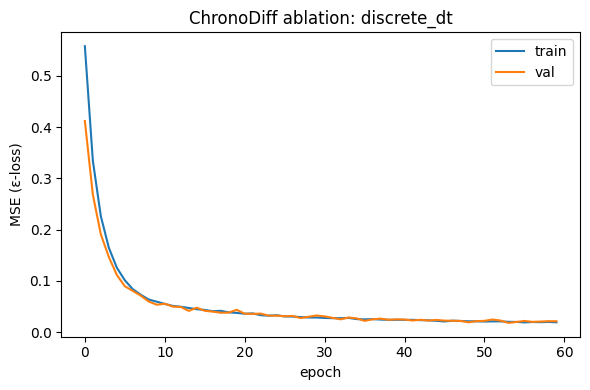

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
plt.plot(hist['train'], label='train'); plt.plot(hist['val'], label='val')
plt.xlabel('epoch'); plt.ylabel('MSE (ε-loss)')
plt.title(f'ChronoDiff ablation: {ABLATION_MODE}'); plt.legend()
plt.tight_layout()
plt.savefig(RESULTS / f'{TAG}_curves.png', dpi=120, bbox_inches='tight')
plt.show()


In [ ]:
@torch.no_grad()
def ddim_sample(z_src, dt, steps=DDIM_STEPS):
    unet.eval()
    B = z_src.size(0)
    z = torch.randn(B, LATENT_CH, LATENT_SIZE, LATENT_SIZE, device=DEVICE)
    ts = torch.linspace(TIMESTEPS - 1, 0, steps + 1, device=DEVICE).long()
    for i in range(steps):
        t_cur, t_nxt = ts[i], ts[i + 1]
        eps = unet(z, t_cur.float().expand(B), dt, z_src)
        ab_t, ab_n = alpha_bar[t_cur], alpha_bar[t_nxt]
        z0 = (z - torch.sqrt(1 - ab_t) * eps) / torch.sqrt(ab_t)
        z  = torch.sqrt(ab_n) * z0 + torch.sqrt(1 - ab_n) * eps
    return decode_latent(z).clamp(-1, 1)


In [ ]:
!pip install lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 5.7 MB/s eta 0:00:00


In [ ]:
USE_LPIPS = True

def to_unit(x):
    """Normalize from [-1, 1] to [0, 1]."""
    return ((x + 1) / 2).clamp(0, 1)

from skimage.transform import resize as skimage_resize

rows = []
for batch in tqdm(test_loader, desc=f'{TAG} eval'):
    src = batch['src'].to(DEVICE)
    tgt = batch['tgt'].to(DEVICE)
    dt  = batch['dt'].to(DEVICE)
    z_src, _ = encode_pair(src, tgt)
    pred = ddim_sample(z_src, dt)

    # Process each item in the batch
    for b_idx in range(pred.shape[0]):
        p_np = to_unit(pred[b_idx:b_idx+1]).cpu().numpy()[0, 0]
        t_np = to_unit(tgt[b_idx:b_idx+1]).cpu().numpy()[0, 0]

        # RESIZE prediction to match target size
        if p_np.shape != t_np.shape:
            p_np = skimage_resize(p_np, t_np.shape, anti_aliasing=True, preserve_range=True)

        row = {
            'slice_id': batch['slice_id'][b_idx],
            'psnr': float(psnr_fn(t_np, p_np, data_range=1.0)),
            'ssim': float(ssim_fn(t_np, p_np, data_range=1.0)),
            'mae' : float(np.abs(t_np - p_np).mean()),
        }
        if USE_LPIPS:
            with torch.no_grad():
                # Ensure both are [1, 3, H, W]
                pred_resized = torch.from_numpy(p_np).unsqueeze(0).unsqueeze(0).float().to(DEVICE)
                tgt_single = tgt[b_idx:b_idx+1]  # [1, 1, H, W]

                # Repeat to [1, 3, H, W]
                lpips_score = lp_net(pred_resized.repeat(1, 3, 1, 1),
                                     tgt_single.repeat(1, 3, 1, 1))
                row['lpips'] = float(lpips_score.item())

        rows.append(row)
        # np.save(PRED_DIR / f'{row["slice_id"]}.npy', p_np)

eval_df = pd.DataFrame(rows)
eval_df.to_csv(RESULTS / f'{TAG}_per_slice.csv', index=False)
print(f'\n=== {TAG} TEST METRICS ===')
print(eval_df[['psnr', 'ssim', 'mae']].describe())

print(f'\nDone.')

chronodiff_discrete_dt eval: 100%|█████████▉| 5422/5441 [1:12:06<00:19,  1.03s/it]